In [30]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sys
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb


PROJECT_ROOT = Path.cwd()
p = Path.cwd().resolve()
while p != p.parent and not (p / "extending_obs_space_analysis").exists():
    p = p.parent
PROJECT_ROOT = p

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)

from pathlib import Path
from extending_obs_space_analysis.prepare_data import PipelinePaths, build_training_dataframe

paths = PipelinePaths(
    drl_csv=Path("../data/data_2019-01-01_2024-12-31_hourly.csv"),
    ri_profit_2019_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv"),
    ri_profit_2023_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2023/bs15cr1rto0.86mc365mt10/profit.csv"),
    da_milp_exaa_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_exaa.csv"),
    da_milp_epex_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_epex.csv"),
)

df_daily = build_training_dataframe(paths, date_slice=("2019-01-01", "2023-12-31"))

Using project root: /Users/timflaschel/Documents/GitHub/BessBidder1


In [31]:
print(df_daily.columns.tolist())

['epex_price_mean', 'epex_price_std', 'epex_price_min', 'epex_price_max', 'exaa_price_mean', 'exaa_price_std', 'exaa_price_min', 'exaa_price_max', 'load_forecast_mean', 'load_forecast_std', 'load_forecast_min', 'load_forecast_max', 'pv_forecast_mean', 'pv_forecast_std', 'pv_forecast_min', 'pv_forecast_max', 'wind_offshore_forecast_mean', 'wind_offshore_forecast_std', 'wind_offshore_forecast_min', 'wind_offshore_forecast_max', 'wind_onshore_forecast_mean', 'wind_onshore_forecast_std', 'wind_onshore_forecast_min', 'wind_onshore_forecast_max', 'residual_load_forecast_mean', 'residual_load_forecast_std', 'residual_load_forecast_min', 'residual_load_forecast_max', 'id_full_h_mean', 'id_full_h_std', 'id_full_h_min', 'id_full_h_max', 'epex_price_spread', 'id_full_h_spread', 'exaa_price_spread', 'residual_load_forecast_spread', 'day_of_week', 'month', 'year', 'epex_price_delta_sum', 'epex_price_delta_max', 'epex_price_delta_min', 'exaa_price_delta_sum', 'exaa_price_delta_max', 'exaa_price_delt

In [32]:
drop_columns = ['epex_price_mean', 'epex_price_std', 'epex_price_min', 'epex_price_max', 
                'id_full_h_mean', 'id_full_h_std', 'id_full_h_min', 'id_full_h_max',
                'epex_price_spread', 'id_full_h_spread',
                   'epex_price_delta_sum', 'epex_price_delta_max' , 'epex_price_delta_min',
                   'da_profit_exaa', 'da_profit_epex', 'da_idc_profit_diff']
df_daily = df_daily.drop(columns=drop_columns)

In [33]:
for col in df_daily.columns:
    print(col)


exaa_price_mean
exaa_price_std
exaa_price_min
exaa_price_max
load_forecast_mean
load_forecast_std
load_forecast_min
load_forecast_max
pv_forecast_mean
pv_forecast_std
pv_forecast_min
pv_forecast_max
wind_offshore_forecast_mean
wind_offshore_forecast_std
wind_offshore_forecast_min
wind_offshore_forecast_max
wind_onshore_forecast_mean
wind_onshore_forecast_std
wind_onshore_forecast_min
wind_onshore_forecast_max
residual_load_forecast_mean
residual_load_forecast_std
residual_load_forecast_min
residual_load_forecast_max
exaa_price_spread
residual_load_forecast_spread
day_of_week
month
year
exaa_price_delta_sum
exaa_price_delta_max
exaa_price_delta_min
pv_delta_sum
pv_delta_max
pv_delta_min
wind_onshore_delta_sum
wind_onshore_delta_max
wind_onshore_delta_min
wind_offshore_delta_sum
wind_offshore_delta_max
wind_offshore_delta_min
residual_load_delta_sum
residual_load_delta_max
residual_load_delta_min
exaa_std_roll3d_mean_lag0
exaa_std_roll7d_mean_lag0
exaa_std_roll14d_mean_lag0
exaa_std_roll

### LGB Regressor 

In [34]:
# Data prep
# ------------------------------------------------------------------

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

# nur numerische ex-ante Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

n = len(df)
print("Total observations:", n)


# Rolling window setup
# ------------------------------------------------------------------

train_size = 730
test_size  = 180
step_size  = 180


# LightGBM Regressor
# ------------------------------------------------------------------

params = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.5,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


# Rolling CV
# ------------------------------------------------------------------

rows = []
models = []

fold = 0
start = 0

while start + train_size + test_size <= n:
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    reg = lgb.LGBMRegressor(**params)
    reg.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    y_pred = reg.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    rows.append({
        "fold": fold,
        "train_start": start,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "best_iter": int(getattr(reg, "best_iteration_", None) or params["n_estimators"])
    })

    models.append(reg)
    start += step_size


# Results
# ------------------------------------------------------------------

rw_df = pd.DataFrame(rows)

print("\nRolling Window CV Results (Point Forecast)")
print(rw_df)

print("\nRolling Window CV Means")
print(rw_df.drop(columns=["fold", "train_start"]).mean(numeric_only=True))



Total observations: 1826

Rolling Window CV Results (Point Forecast)
   fold  train_start        MAE        RMSE        R2  best_iter
0     1            0  29.577739   41.402042  0.403402         58
1     2          180  60.975345   89.654516  0.344661       1045
2     3          360  64.949577   99.581159  0.287992        113
3     4          540  98.513435  146.922296  0.396401        162
4     5          720  54.512084   75.971311  0.176491         83
5     6          900  68.515267  180.838355  0.218670        944

Rolling Window CV Means
MAE           62.840575
RMSE         105.728280
R2             0.304603
best_iter    400.833333
dtype: float64


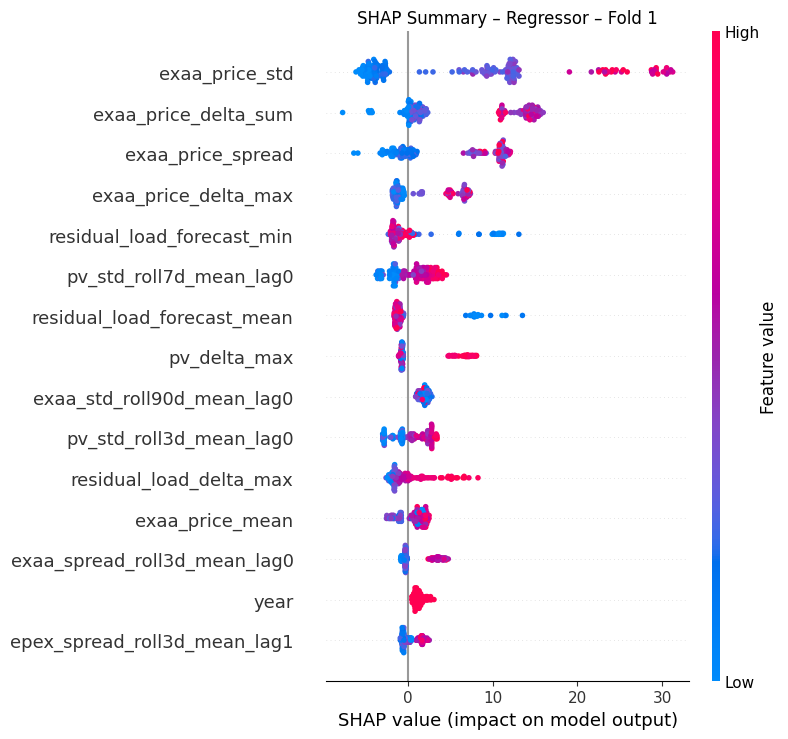

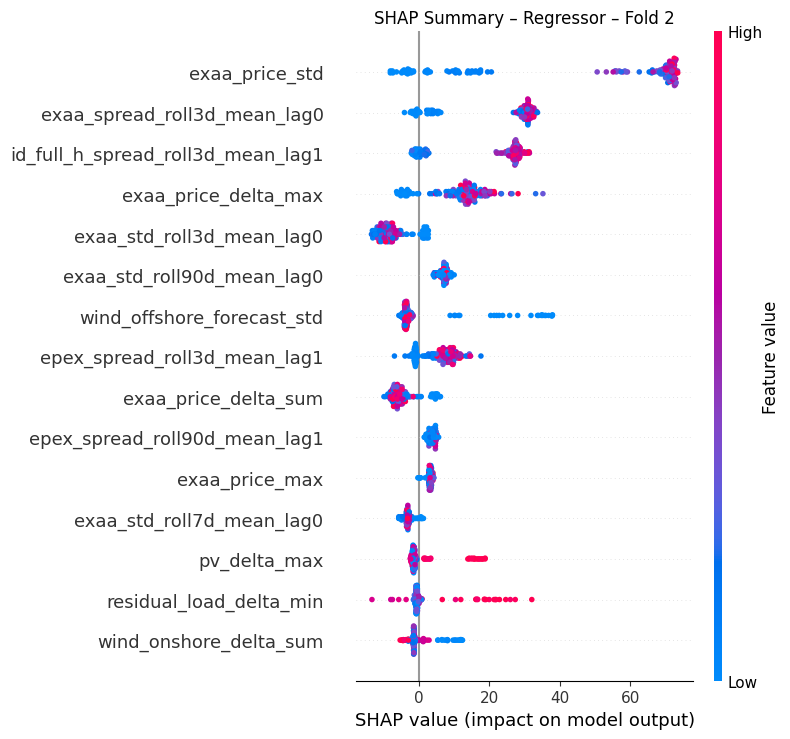

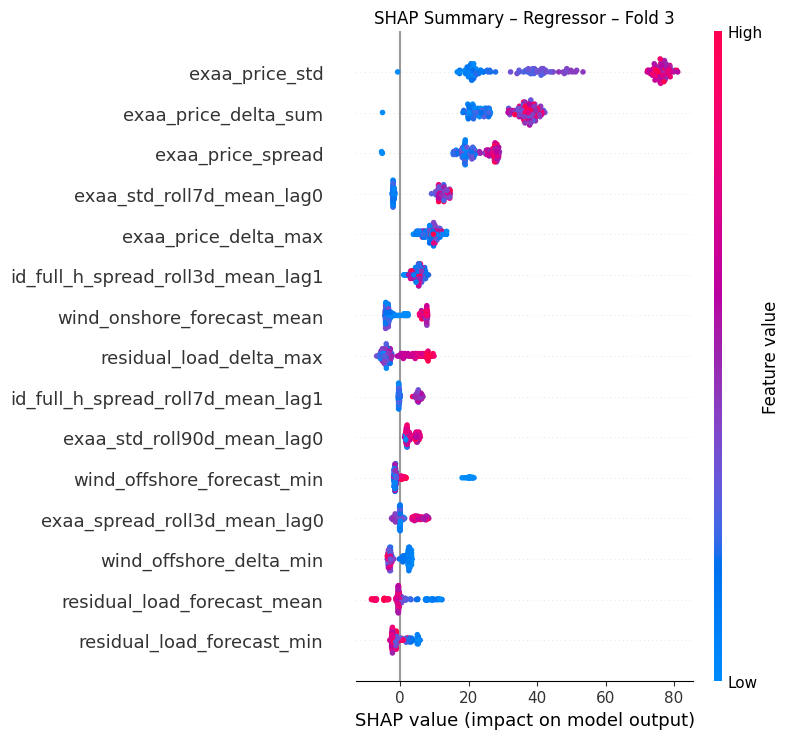

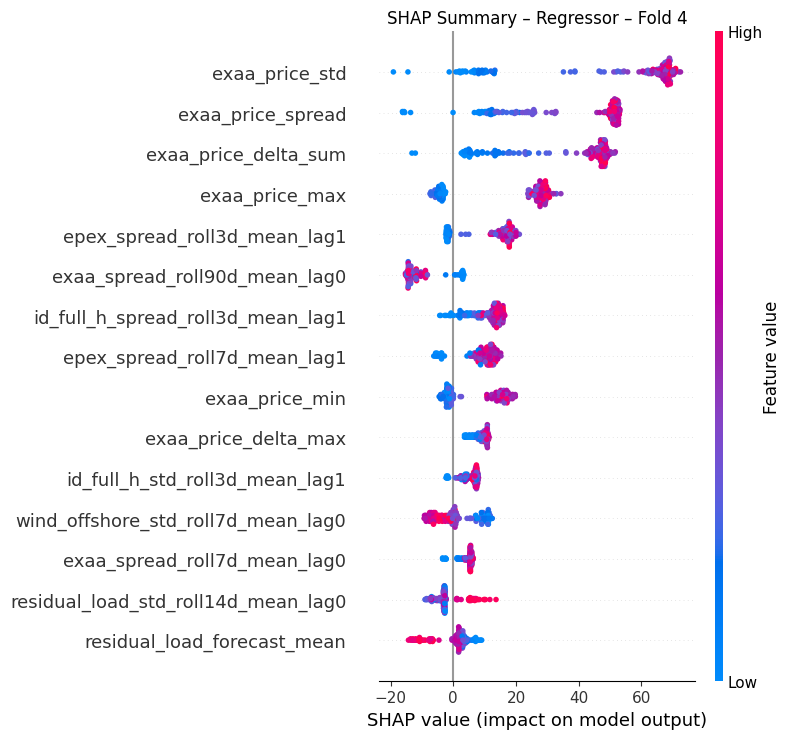

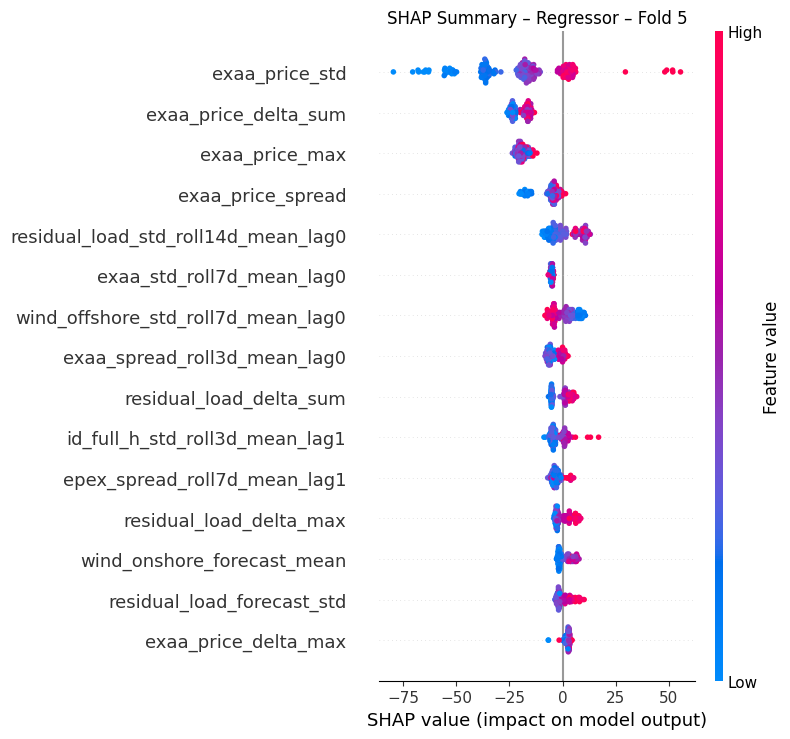

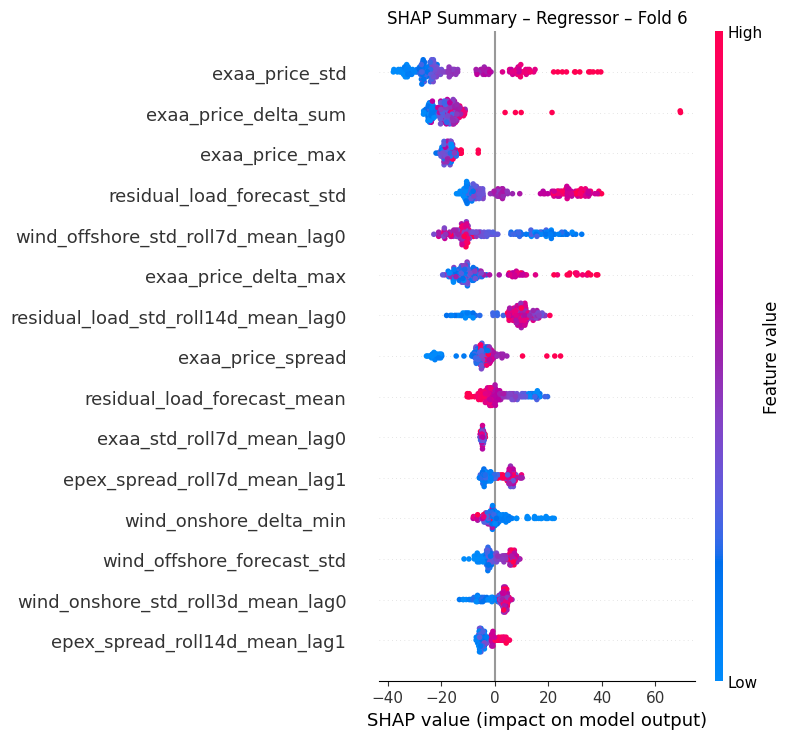

                                          mean        std
feature                                                  
exaa_price_std                       34.826463  18.502148
exaa_price_delta_sum                 19.850350  12.425993
exaa_price_spread                    13.845519  13.975998
exaa_price_max                       10.268892   9.640544
exaa_price_delta_max                  8.155837   4.478670
id_full_h_spread_roll3d_mean_lag1     6.605153   7.080480
exaa_spread_roll3d_mean_lag0          5.416295   8.724360
epex_spread_roll3d_mean_lag1          4.479288   5.033896
wind_offshore_std_roll7d_mean_lag0    4.411606   4.702369
residual_load_std_roll14d_mean_lag0   4.045985   3.909219
exaa_std_roll7d_mean_lag0             3.733947   3.415258
residual_load_forecast_std            3.526572   5.866192
epex_spread_roll7d_mean_lag1          3.253156   3.847106
residual_load_forecast_mean           3.173472   1.558979
residual_load_delta_max               2.808384   0.994230
id_full_h_std_

In [35]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt


from sklearn.impute import SimpleImputer

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

train_size = 730
test_size  = 180
step_size  = 180

params = dict(
    objective="regression",
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

shap_results = []

fold = 0
start = 0

while start + train_size + test_size <= len(df):
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    # leakage-freie Imputation
    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=feature_cols,
        index=X_train.index
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=feature_cols,
        index=X_test.index
    )

    reg = lgb.LGBMRegressor(**params)
    reg.fit(
        X_train_imp, y_train,
        eval_set=[(X_test_imp, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    # --- SHAP: robust (kein Additivity-Error) ---
    explainer = shap.TreeExplainer(reg, data=X_train_imp)

    tree_limit = getattr(reg, "best_iteration_", None)
    shap_vals = explainer.shap_values(
        X_test_imp,
        check_additivity=False,
        tree_limit=tree_limit
    )

    # shap_vals: (n_samples, n_features)
    shap_vals = np.asarray(shap_vals)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_results.append(pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": mean_abs_shap,
        "fold": fold
    }))

    # Summary plot
    plt.figure()
    shap.summary_plot(
        shap_vals,
        X_test_imp,
        feature_names=feature_cols,
        show=False,
        max_display=15
    )
    plt.title(f"SHAP Summary – Regressor – Fold {fold}")
    plt.tight_layout()
    plt.show()

    start += step_size

shap_df = pd.concat(shap_results, ignore_index=True)

# Optional: Aggregation über Folds
shap_summary = (
    shap_df.groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(shap_summary.head(20))



#### LGB Classifier

In [39]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# Helper metrics
# ------------------------------------------------------------------

def precision_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    return float(np.mean(y_true[idx]))

def recall_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    denom = np.sum(y_true)
    return float(np.sum(y_true[idx]) / denom) if denom > 0 else np.nan

# Data prep
# ------------------------------------------------------------------

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

# nur numerische ex-ante Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

n = len(df)
print("Total observations:", n)

# Rolling window setup
# ------------------------------------------------------------------

train_size = 730
test_size  = 180
step_size  = 180

q_high = 0.8
k_frac = 0.20

# LightGBM parameters
# ------------------------------------------------------------------

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.5,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Rolling CV
# ------------------------------------------------------------------

rows = []
models = []

fold = 0
start = 0

while start + train_size + test_size <= n:
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]

    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    # Threshold nur aus Train
    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    # skip folds ohne beide Klassen
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    p_test = clf.predict_proba(X_test)[:, 1]

    rows.append({
        "fold": fold,
        "train_start": start,
        "thr_profit": float(thr),
        "test_pos_rate": float(y_test.mean()),
        "AUC": roc_auc_score(y_test, p_test),
        f"Precision@{int(k_frac*100)}%": precision_at_k(y_test, p_test, k_frac),
        f"Recall@{int(k_frac*100)}%": recall_at_k(y_test, p_test, k_frac),
        "best_iter": int(clf.best_iteration_ or params["n_estimators"])
    })

    models.append(clf)
    start += step_size

# Results
# ------------------------------------------------------------------

rw_df = pd.DataFrame(rows)

print("\nRolling Window CV Results")
print(rw_df)

print("\nRolling Window CV Means")
print(rw_df.drop(columns=["fold", "train_start"]).mean(numeric_only=True))



Total observations: 1826

Rolling Window CV Results
   fold  train_start  thr_profit  test_pos_rate       AUC  Precision@20%  \
0     1            0  105.496038       0.444444  0.850750       0.888889   
1     2          180  120.773462       0.794444  0.894349       0.972222   
2     3          360  180.799808       0.927778  0.863197       1.000000   
3     4          540  276.507247       0.777778  0.946339       1.000000   
4     5          720  381.457728       0.027778  0.766286       0.055556   
5     6          900  392.886905       0.055556  0.945294       0.277778   

   Recall@20%  best_iter  
0    0.400000         67  
1    0.244755         67  
2    0.215569        130  
3    0.257143         18  
4    0.400000         23  
5    1.000000         61  

Rolling Window CV Means
thr_profit       242.986865
test_pos_rate      0.504630
AUC                0.877702
Precision@20%      0.699074
Recall@20%         0.419578
best_iter         61.000000
dtype: float64


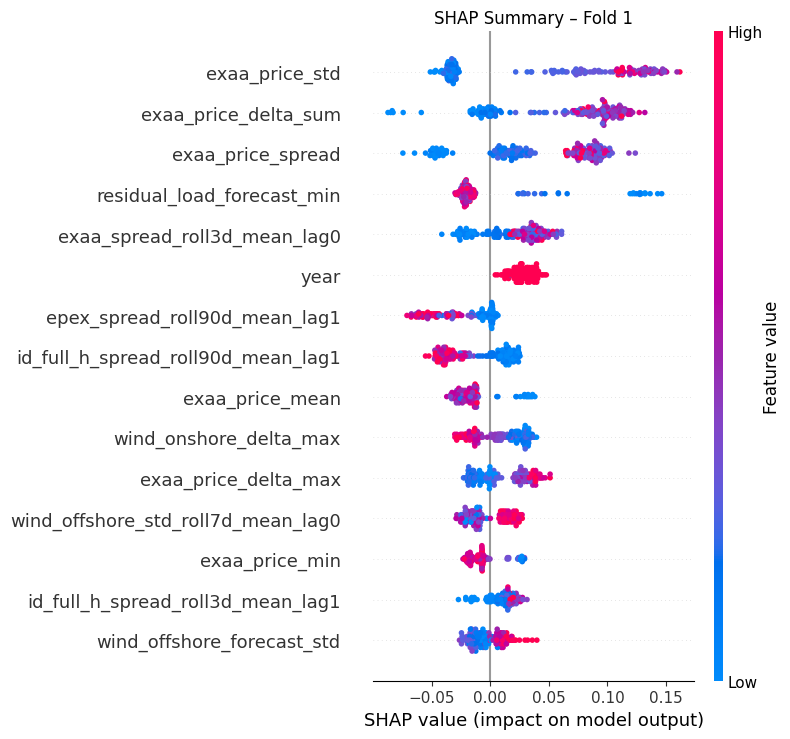

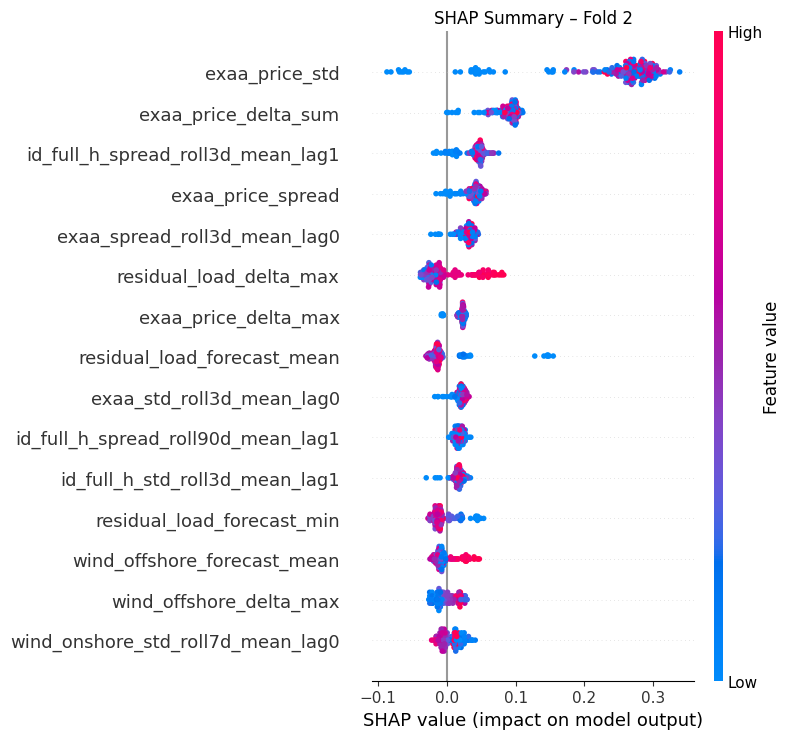

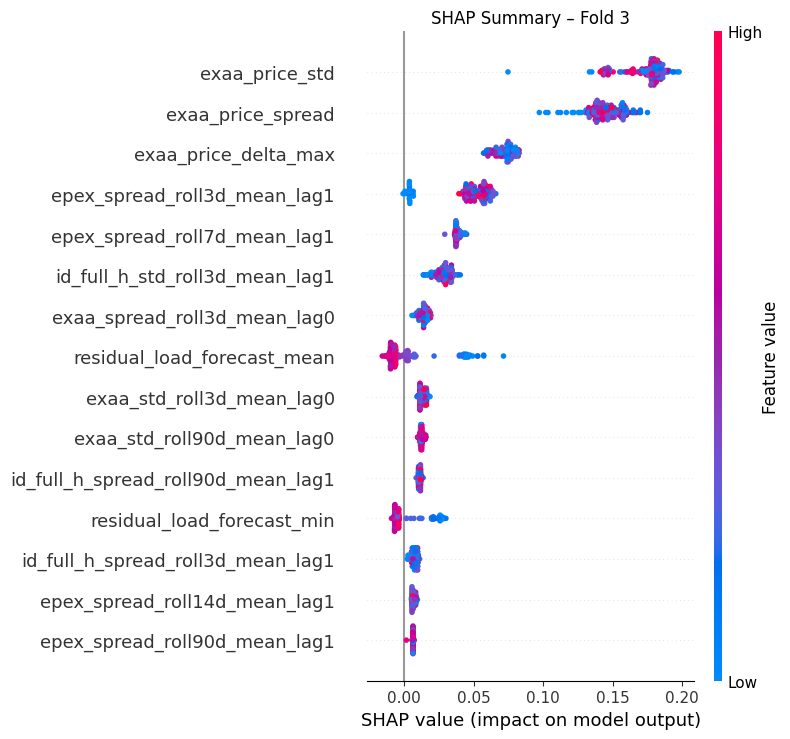

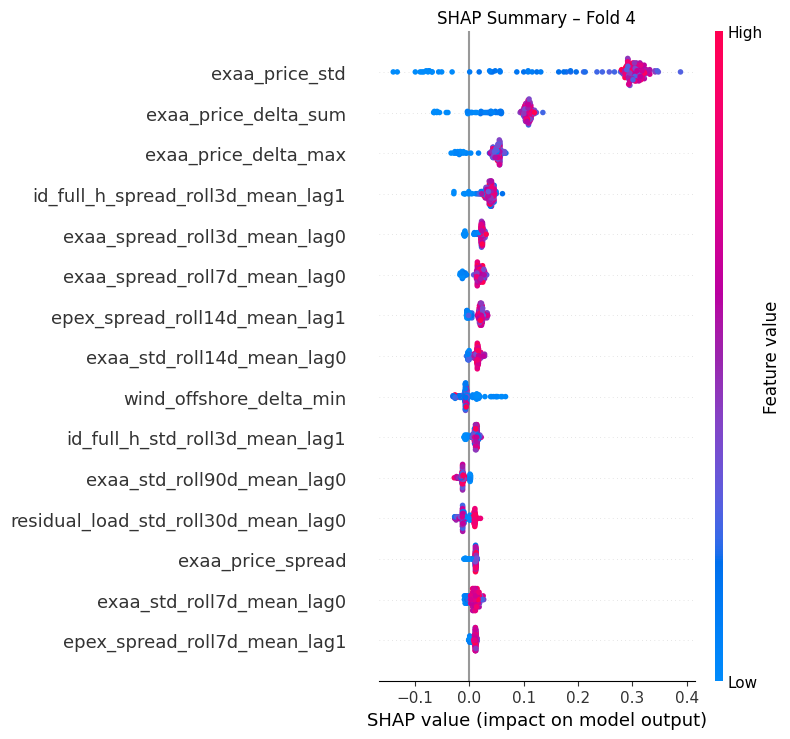

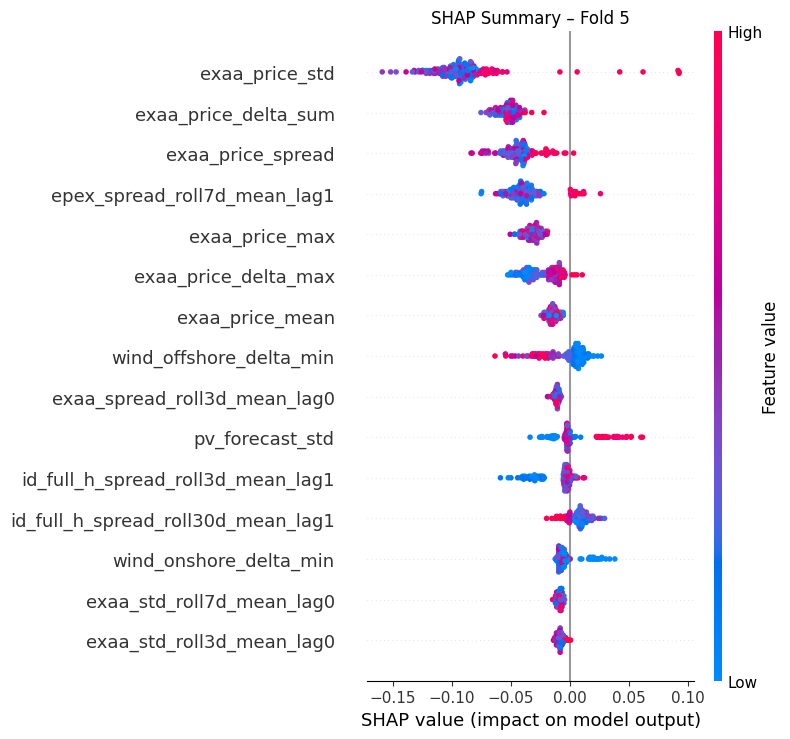

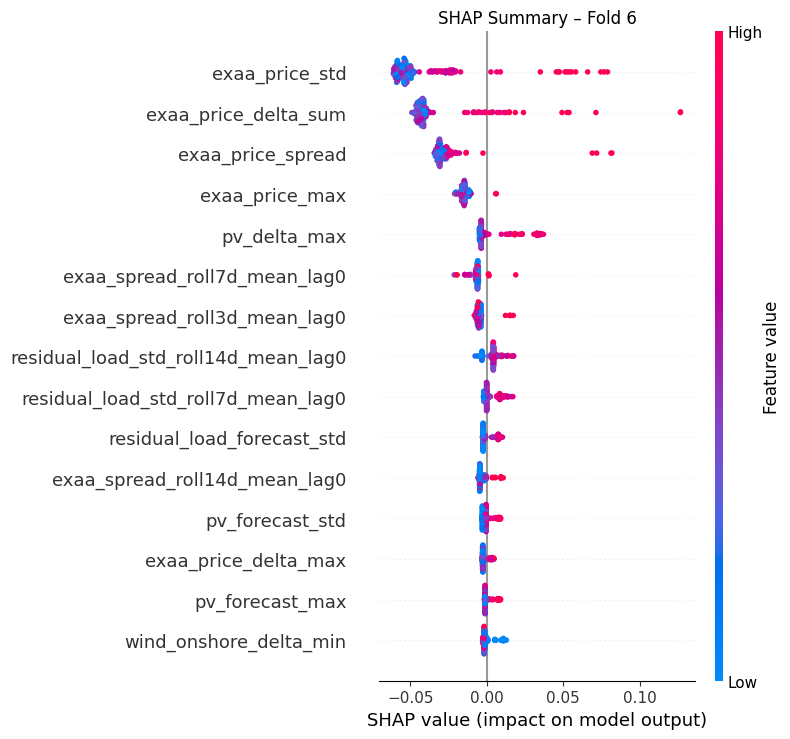

In [ ]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# Rolling Window Parameter
train_size = 730
test_size  = 180
step_size  = 180
q_high     = 0.7

params = dict(
    objective="binary",
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

shap_results = []

fold = 0
start = 0

while start + train_size + test_size <= len(df):
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    explainer = shap.Explainer(
        clf,
        X_train,
        model_output="probability"
    )

    shap_exp = explainer(X_test)

    # Matrix: (n_samples, n_features)
    shap_vals = shap_exp.values

    assert shap_vals.ndim == 2
    assert shap_vals.shape[1] == X_test.shape[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_results.append(
        pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap,
            "fold": fold
        })
    )



    
    # Shap sumamry plot
    plt.figure()
    shap.summary_plot(
        shap_vals, X_test,
        feature_names=feature_cols,
        show=False,
        max_display=15
    )
    
    plt.title(f"SHAP Summary – Fold {fold}")
    plt.tight_layout()
    plt.show()
    
    start += step_size

shap_df = pd.concat(shap_results, ignore_index=True)


In [38]:
# aggregate SHAP values over all folds
shap_agg = (
    shap_df
    .groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(shap_agg.head(50))


                                         mean       std
feature                                                
exaa_price_std                       0.147901  0.087877
exaa_price_delta_sum                 0.057580  0.032305
exaa_price_spread                    0.053889  0.047134
exaa_price_delta_max                 0.031309  0.024874
exaa_spread_roll3d_mean_lag0         0.018706  0.010123
id_full_h_spread_roll3d_mean_lag1    0.018356  0.016018
epex_spread_roll7d_mean_lag1         0.016879  0.016998
id_full_h_std_roll3d_mean_lag1       0.011677  0.010642
exaa_price_max                       0.010705  0.011236
residual_load_forecast_min           0.010658  0.011267
residual_load_delta_max              0.009579  0.009547
epex_spread_roll3d_mean_lag1         0.009318  0.018728
id_full_h_spread_roll90d_mean_lag1   0.009064  0.010654
exaa_std_roll3d_mean_lag0            0.008279  0.007664
residual_load_forecast_mean          0.008269  0.008155
exaa_spread_roll7d_mean_lag0         0.007825  0